In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

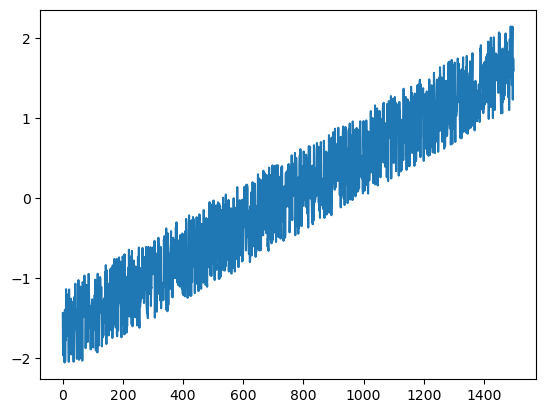

In [2]:
X = np.array(range(1500))
Y = 5 * X + 3 + np.random.randint(-800, 1600, 1500)

X = (X - np.mean(X)) / np.std(X) 
Y = (Y - np.mean(Y)) / np.std(Y)

lr = 0.1
N = len(X)

sns.lineplot(Y)
plt.show()

## Градиентный спуск

Известно, что градиент является направлением наискорейшего роста функции,
а антиградиент (т.е. $-\nabla f$) — направлением наискорейшего убывания.
Это ключевое свойство градиента, обосновывающее его использование в методах оптимизации.
Основное свойство антиградиента — он указывает в сторону наискорейшего убывания функции в данной точке.
Соответственно, будет логично стартовать из некоторой точки, сдвинуться в сторону антиградиента,
пересчитать антиградиент и снова сдвинуться в его сторону и т.д.
Запишем это более формально.

Пусть $w^{(0)}$ — начальный набор параметров (например, нулевой или сгенерированный из некоторого
случайного распределения).

Тогда градиентный спуск состоит в повторении следующих шагов до сходимости:

$$
w^{(k)} = w^{(k-1)} - \eta_k \nabla Q(w^{(k-1)}) \tag{1}
$$

Здесь под $Q(w)$ понимается значение функционала ошибки для набора параметров $w$.
Через $\eta_k$ обозначается длина шага, которая нужна для контроля скорости движения.
Можно делать её константной: $\eta_k = c$.

При этом если длина шага слишком большая, то есть риск постоянно «перепрыгивать» через точку минимума,
а если шаг слишком маленький, то движение к минимуму может занять слишком много итераций.

Иногда длину шага монотонно уменьшают по мере движения — например, по простой формуле

$$
\eta_k = \frac{1}{k}.
$$

Коэффициент наклона: 0.9508 Свободный член: 0.0001
Количество итераций: 44


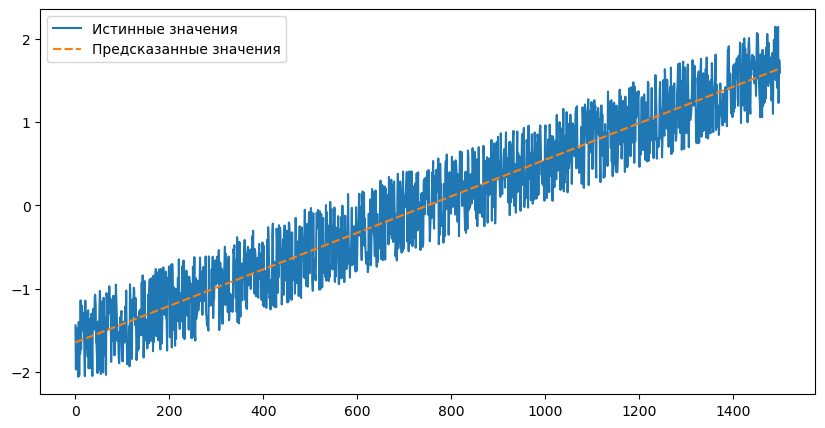

CPU times: total: 172 ms
Wall time: 179 ms


In [3]:
%%time

a0 = np.random.normal(0, 1, 1)
b0 = np.random.normal(0, 1, 1)
i0 = 0
error1 = float('inf')

while i0 <= 10000:
     f = X * a0 + b0

     error0 = np.mean((f - Y) ** 2)

     dl_da = 2 / N * np.sum((f - Y) * X)
     dl_db = 2 / N * np.sum(f - Y)
     
     a0 -= lr * dl_da
     b0 -= lr * dl_db

     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i0 += 1

print('Коэффициент наклона:', np.round(a0[0], 4), 'Свободный член:', np.round(b0[0], 4)) 
print('Количество итераций:', i0)
Y0 = a0 * X + b0
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y0})
plt.show()

## Стохастический градиентный спуск

Оценить градиент суммы функций можно градиентом одного случайно взятого слагаемого:

$$
\nabla_w Q(w) \approx \nabla_w q_{i_k}(w),
$$

где $i_k$ — случайно выбранный номер слагаемого из функционала.
В этом случае мы получим метод *стохастического градиентного спуска* (stochastic gradient descent, SGD):

$$
w^{(k)} = w^{(k-1)} - \eta_k \nabla q_{i_k}(w^{(k-1)}).
$$

У обычного градиентного спуска есть важная особенность:
чем ближе текущая точка к минимуму, тем меньше в ней градиент,
за счёт чего процесс замедляется и аккуратно попадает в окрестность минимума.
В случае со стохастическим градиентным спуском это свойство теряется.
На каждом шаге мы двигаемся в сторону, оптимальную с точки зрения уменьшения ошибки на одном объекте.
Параметры, оптимальные для средней ошибки на всей выборке, не обязаны являться оптимальными
для ошибки на одном из объектов.
Поэтому SGD метод запросто может отдаляться от минимума, даже оказавшись рядом с ним.

Чтобы исправить эту проблему, важно в SGD делать длину шага убывающей —
тогда в окрестности оптимума мы уже не сможем делать длинные шаги и, как следствие,
не сможем из этой окрестности выйти.
Разумеется, потребуется выбирать формулу для длины шага аккуратно, чтобы не остановиться слишком рано
и не уйти от минимума.

В частности, сходимость для выпуклых дифференцируемых функций гарантируется (с вероятностью 1),
если функционал удовлетворяет ряду условий (как правило, это выпуклость, дифференцируемость и липшицевость градиента)
и длина шага удовлетворяет условиям Роббинса–Монро:

$$
\sum_{k=1}^{\infty} \eta_k = \infty; \quad \sum_{k=1}^{\infty} \eta_k^2 < \infty.
$$

Этим условиям, например, удовлетворяет шаг $\eta_k = \frac{1}{k}$.
На практике сходимость с ним может оказаться слишком медленной,
поэтому правильнее будет подбирать формулу для длины шага более аккуратно.

Для выпуклого и гладкого функционала может быть получена следующая оценка:

$$
\mathbb{E} \left[ Q(w^{(k)}) - Q(w^*) \right] = O(1 / \sqrt{k}).
$$

Таким образом, метод стохастического градиента имеет менее
трудоемкие итерации по сравнению с полным градиентом,
но и скорость сходимости у него существенно меньше.
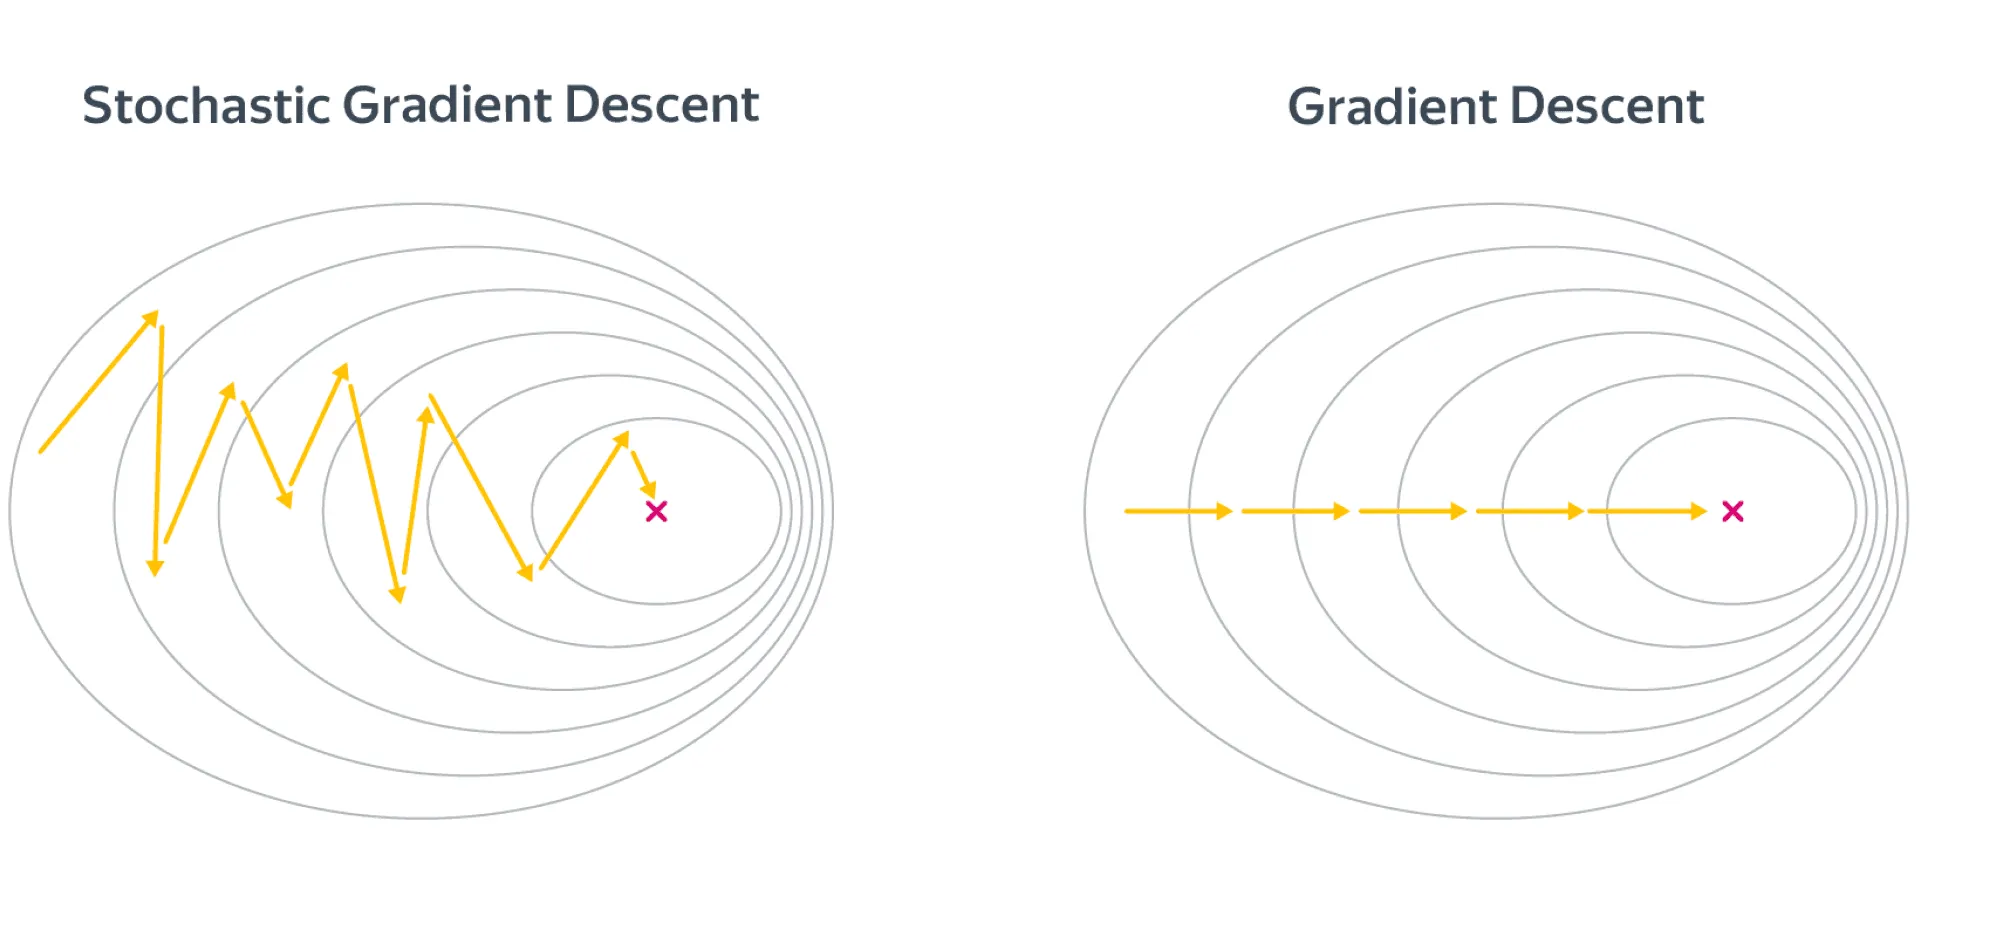

Коэффициент наклона: 0.9528 Свободный член: -0.0008
Количество итераций: 15000


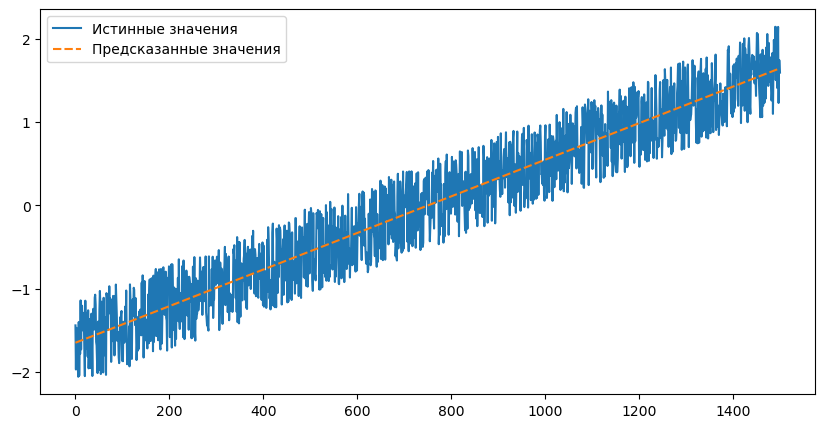

CPU times: total: 562 ms
Wall time: 562 ms


In [6]:
%%time

a1 = np.random.normal(0, 1, 1)
b1 = np.random.normal(0, 1, 1)

epoch = 0
error1 = float('inf')
batch_size = 100
batch_count = N // batch_size
i1 = 0

while epoch < 1000:

     indices = np.random.permutation(N)
     X_shuffled = X[indices]
     Y_shuffled = Y[indices]

     for b in range(batch_count):
          X1 = X_shuffled[b *  batch_size : b * batch_size + batch_size]
          Y1 = Y_shuffled[b * batch_size : b * batch_size + batch_size]

          f1 = X1 * a1 + b1

          dl_da = 2 / batch_size  * np.sum((f1 - Y1) * X1)
          dl_db = 2 / batch_size * np.sum(f1 - Y1)

          a1 -= lr * dl_da
          b1 -= lr * dl_db

     f = X_shuffled * a1 + b1

     error0 = np.mean((f - Y_shuffled) ** 2)
     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     epoch += 1
     i1 += batch_count

print('Коэффициент наклона:', np.round(a1[0], 4), 'Свободный член:', np.round(b1[0], 4)) 
print('Количество итераций:', i1)
Y1 = a1 * X + b1
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y1})
plt.show()

## Accelerated Gradient Descend

Коэффициент наклона: 0.951 Свободный член: 0.0
Количество итераций: 44


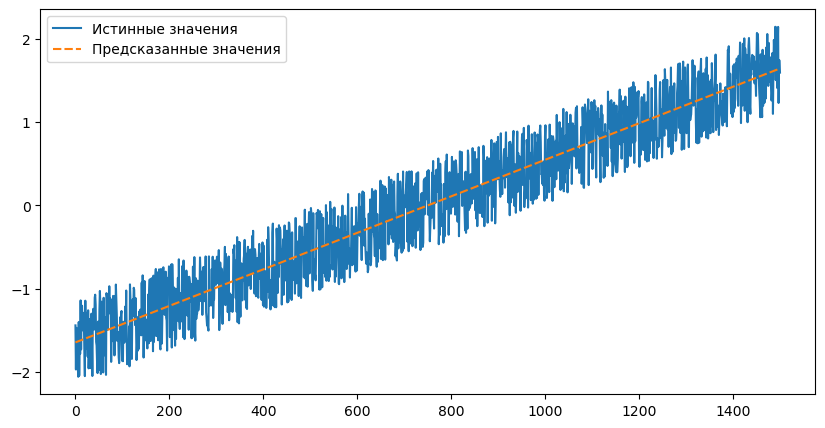

CPU times: total: 172 ms
Wall time: 172 ms


In [8]:
%%time

a2 = np.random.normal(0, 1, 1)
b2 = np.random.normal(0, 1, 1)
i2 = 0
error1 = float('inf')
Va, Vb = 0, 0
beta = 0.9

while i2 <= 10000:
     a_nesterov = a2 + beta * Va
     b_nesterov = b2 + beta * Vb
    
     f_nesterov = a_nesterov * X + b_nesterov

     dl_da = 2 / N * np.sum((f_nesterov - Y) * X)
     dl_db = 2 / N * np.sum(f_nesterov - Y)

     Va = beta * Va - lr * dl_da
     a2 += Va

     Vb = beta * Vb - lr * dl_db
     b2 += Vb

     f = a2 * X + b2

     error0 = np.mean((f - Y) ** 2)
     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i2 += 1

print('Коэффициент наклона:', np.round(a2[0], 4), 'Свободный член:', np.round(b2[0], 4)) 
print('Количество итераций:', i2)
Y2 = a2 * X + b2
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y2})
plt.show()

## ADAptive GRADient descend

Градиентный спуск очень чувствителен к выбору длины шага.
Если шаг большой, то есть риск, что мы будем «перескакивать» через точку минимума;
если же шаг маленький, то для нахождения минимума потребуется много итераций.
При этом нет способов заранее определить правильный размер шага — к тому же,
схемы с постепенным уменьшением шага по мере итераций могут тоже плохо работать.

В методе AdaGrad предлагается сделать свою длину шага для каждой компоненты вектора параметров.
При этом шаг будет тем меньше, чем более длинные шаги мы делали на предыдущих итерациях:

$$
\begin{aligned}
&G_{kj} = G_{k-1,j} + \left(\nabla_w Q(w^{(k-1)})\right)_j^2;\\
&w_j^{(k)} = w_j^{(k-1)} - \frac{\eta_t}{\sqrt{G_{kj} + \varepsilon}} \left(\nabla_w Q(w^{(k-1)})\right)_j.
\end{aligned}
$$

Здесь $\varepsilon$ — небольшая константа, которая предотвращает деление на ноль.
В данном методе можно зафиксировать длину шага (например, $\eta_k = 0.01$)
и не подбирать её в процессе обучения.
Отметим, что данный метод подходит для разреженных задач, в которых у каждого объекта большинство признаков равны нулю.
Для признаков, у которых ненулевые значения встречаются редко, будут делаться большие шаги;
если же какой-то признак часто является ненулевым, то шаги по нему будут небольшими.

У метода AdaGrad есть большой недостаток: переменная $G_{kj}$ монотонно растёт,
из-за чего шаги становятся всё медленнее и могут остановиться ещё до того,
как достигнут минимум функционала.

Коэффициент наклона: 0.9503 Свободный член: -0.0
Количество итераций: 565


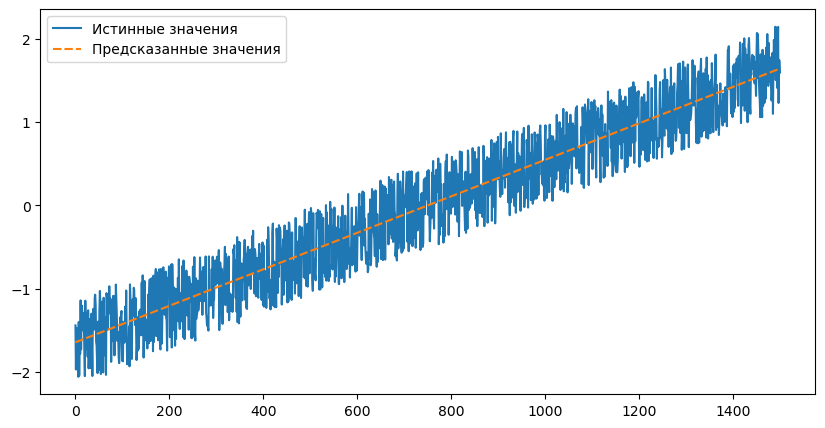

CPU times: total: 188 ms
Wall time: 181 ms


In [9]:
%%time

a3, b3 = np.random.normal(0, 1, 1), np.random.normal(0, 1, 1)
i3 = 0
error1 = float('inf')
Ga, Gb = 0, 0
epsilon = 0.0001

while i3 <= 10000:
     f = X * a3 + b3

     error0 = np.mean((f - Y) ** 2)

     dl_da = 2 / N * np.sum((f - Y) * X)
     dl_db = 2 / N * np.sum(f - Y)

     Ga += dl_da ** 2
     Gb += dl_db ** 2
     # Всегда растёт
     
     a3 -= lr / np.sqrt(Ga + epsilon) * dl_da
     b3 -= lr / np.sqrt(Gb + epsilon) * dl_db
     # Всегда уменьшается шаг, в какой-то момент становится близким к 0

     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i3 += 1

print('Коэффициент наклона:', np.round(a3[0], 4), 'Свободный член:', np.round(b3[0], 4)) 
print('Количество итераций:', i3)
Y3 = a3 * X + b3
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y3})
plt.show()

## Root Mean Square Propagation

Проблема решается в методе RMSprop, где используется экспоненциальное затухание градиентов:

$$
G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) \left(\nabla_w Q(w^{(k-1)})\right)_j^2.
$$

В этом случае размер шага по координате зависит в основном от того, насколько
быстро мы двигались по ней на последних итерациях.

Коэффициент наклона: 0.9509 Свободный член: -0.0
Количество итераций: 14


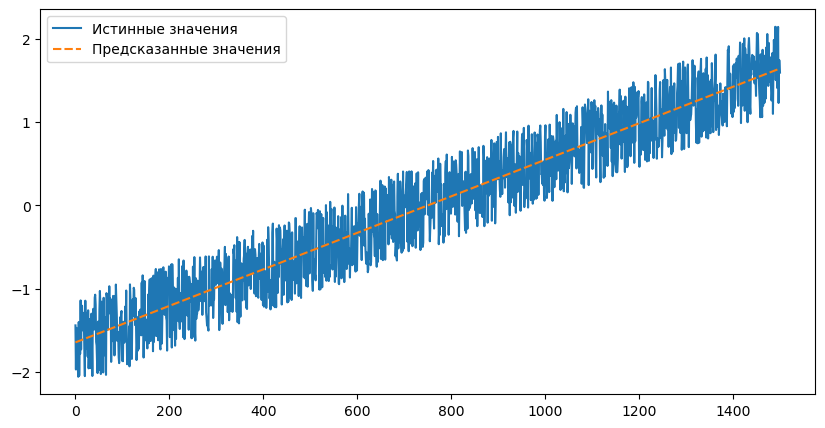

CPU times: total: 156 ms
Wall time: 165 ms


In [10]:
%%time

a4, b4 = np.random.normal(0, 1, 1), np.random.normal(0, 1, 1)
i4 = 0
error1 = float('inf')
Ga, Gb = 0, 0
epsilon = 0.0001
gamma = 0.9

while i4 <= 10000:
     f = X * a4 + b4

     error0 = np.mean((f - Y) ** 2)

     dl_da = 2 / N * np.sum((f - Y) * X)
     dl_db = 2 / N * np.sum(f - Y)

     Ga = gamma * Ga + (1 - gamma) * dl_da ** 2
     Gb = gamma * Gb + (1 - gamma) * dl_db ** 2
     
     a4 -= lr / np.sqrt(Ga + epsilon) * dl_da
     b4 -= lr / np.sqrt(Gb + epsilon) * dl_db

     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i4 += 1

print('Коэффициент наклона:', np.round(a4[0], 4), 'Свободный член:', np.round(b4[0], 4)) 
print('Количество итераций:', i4)
Y4 = a4 * X + b4
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y4})
plt.show()

## ADAptive Momentum

# Объединяем все вместе…

## Adam

Теперь покажем гвоздь нашей программы: алгоритм Adam, который считается решением по умолчанию и практически серебряной пулей в задачах стохастической оптимизации.

Название Adam = **Ada**ptive **M**omentum намекает на то, что мы объединим идеи двух последних разделов в один алгоритм. Приведем его алгоритм, он будет немного отличаться от оригинальной статьи отсутствием коррекций смещения (bias correction), но идея останется той же самой:

$$
v_{k+1} = \beta_1 v_k + (1 - \beta_1) \nabla f(x_k) \tag{1}
$$

$$
G_{k+1} = \beta_2 G_k + (1 - \beta_2) (\nabla f(x_k))^2 \tag{2}
$$

$$
x_{k+1} = x_k - \frac{\alpha}{\sqrt{G_{k+1}} + \varepsilon} v_{k+1} \tag{3}
$$

Как правило, в этом алгоритме подбирают лишь один гиперпараметр $\alpha$ – learning rate. Остальные же: $\beta_1$, $\beta_2$ и $\varepsilon$ – оставляют стандартными и равными 0.9, 0.99 и 1e-8 соответственно. Подбор $\alpha$ составляет главное искусство.
Как правило, в этом алгоритме подбирают лишь один гиперпараметр $\alpha$ – learning rate. Остальные же: $\beta_1$, $\beta_2$ и $\varepsilon$ – оставляют стандартными и равными 0.9, 0.99 и 1e-8 соответственно. Подбор $\alpha$ составляет главное искусство.

Зачастую, при начале работы с реальными данными начинают со значения learning rate равного 3e-4. История данного значения достаточно забавна: в 2016 году Андрей Карпатый (Andrej Karpathy) опубликовал шутливый пост в Twitter.
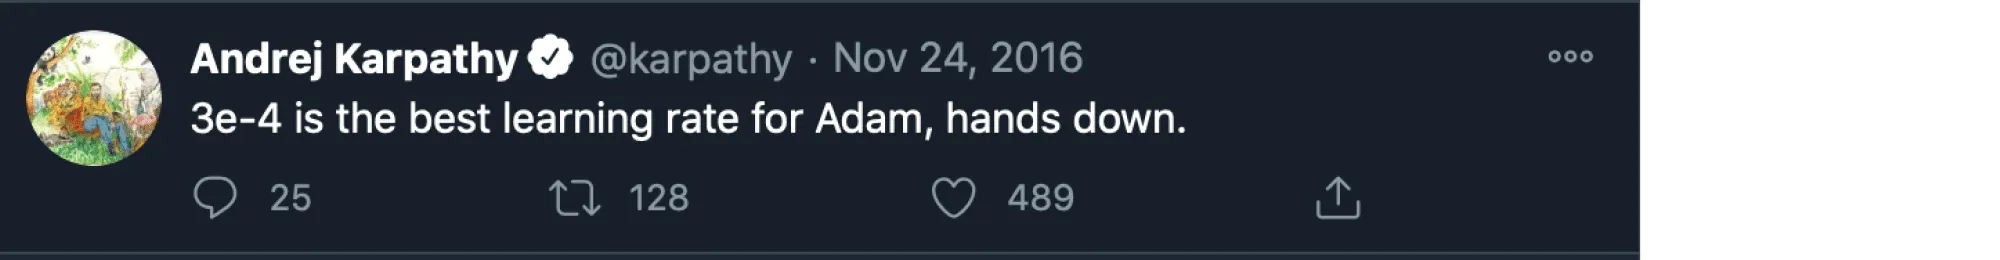
Также стоит помнить, что Adam требует хранения как параметров модели, так и градиентов, накопленного импульса и нормировочных констант (cache). Т.е. достижение более быстрой (с точки зрения количества итераций/объема рассмотренных данных) сходимости требует больших объемов памяти. Кроме того, если вы решите продолжить обучение модели, остановленное на некоторой точке, необходимо восстановить из чекпоинта не только веса модели, но и накопленные параметры Adam. В противном случае оптимизатор начнёт сбор всех своих статистик с нуля, что может сильно сказаться на качестве дообучения. То же самое касается вообще всех описанных выше методов, так как каждый из них накапливает какие-то статистики во время обучения.

Интересный факт: Adam расходится на одномерном контрпримере, что совершенно не мешает использовать его для обучения нейронных сетей. Этот факт отлично демонстрирует, насколько расходятся теория и практика в машинном обучении. В той же работе предложено исправление этого недоразумения, но его активно не применяют и продолжают пользоваться «неправильным» Adamом потому что он быстрее сходится на практике.
# AdamW

А теперь давайте добавим $l_2$-регуляризацию неявным образом, напрямую в оптимизатор и минуя адаптивный размер шага:

$$
v_{k+1} = \beta_1 v_k + (1 - \beta_1) \nabla f(x_k) \tag{4}
$$

$$
G_{k+1} = \beta_2 G_k + (1 - \beta_2) (\nabla f(x_k))^2 \tag{5}
$$

$$
x_{k+1} = x_k - \left( \frac{\alpha}{\sqrt{G_{k+1}} + \varepsilon} v_{k+1} + \lambda x_k \right) \tag{6}
$$

Это сделано для того, чтобы эффект $l_2$-регуляризации не затухал со временем и обобщающая способность модели была выше. Оставим ссылку на одну заметку про этот эффект. Отметим, впрочем, что этот алгоритм особо не используется.

Коэффициент наклона: 0.9512 Свободный член: -0.0001
Количество итераций: 156


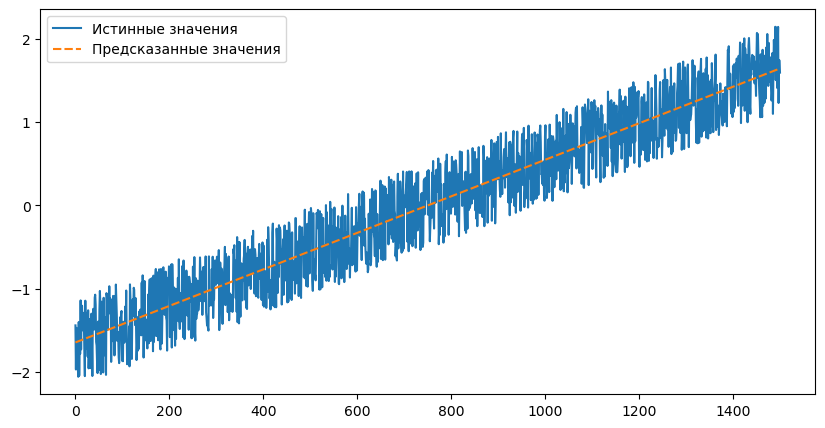

CPU times: total: 172 ms
Wall time: 170 ms


In [11]:
%%time

a5, b5 = np.random.normal(0, 1, 1), np.random.normal(0, 1, 1)
i5 = 0
error1 = float('inf')
Ga, Gb = 0, 0
Va, Vb = 0, 0
epsilon = 1e-8
beta1 = 0.9
beta2 = 0.999

while i5 <= 10000:
     f = X * a5 + b5

     error0 = np.mean((f - Y) ** 2)

     dl_da = 2 / N * np.sum((f - Y) * X)
     dl_db = 2 / N * np.sum(f - Y)

     Va = beta1 * Va + (1 - beta1) * dl_da
     Vb = beta1 * Vb + (1 - beta1) * dl_db

     Ga = beta2 * Ga + (1 - beta2) * dl_da ** 2
     Gb = beta2 * Gb + (1 - beta2) * dl_db ** 2
     
     a5 -= lr / np.sqrt(Ga + epsilon) * Va
     b5 -= lr / np.sqrt(Gb + epsilon) * Vb

     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i5 += 1

print('Коэффициент наклона:', np.round(a5[0], 4), 'Свободный член:', np.round(b5[0], 4)) 
print('Количество итераций:', i5)
Y5 = a5 * X + b5
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y5})
plt.show()

In [13]:
import pandas as pd

Корреляция данных и метода Gradient: 0.9508894075692421
Корреляция данных и метода Stochastic Gradient: 0.9508894075692426
Корреляция данных и метода Accelerated Gradient: 0.9508894075692421
Корреляция данных и метода ADAGrad: 0.9508894075692421
Корреляция данных и метода RMSProb: 0.9508894075692421
Корреляция данных и метода ADAM: 0.950889407569242


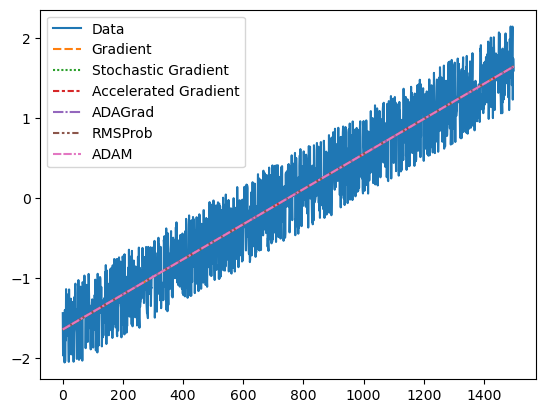

In [14]:
grad_data = pd.DataFrame(data=np.array([Y, Y0, Y1, Y2, Y3, Y4, Y5]).T, 
columns=['Data', 'Gradient', 'Stochastic Gradient', 'Accelerated Gradient', 'ADAGrad', 'RMSProb', 'ADAM'])

for i in grad_data.columns[1::]:
    print(f'Корреляция данных и метода {i}:', grad_data['Data'].corr(grad_data[i]))

sns.lineplot(grad_data)
plt.show()